In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import json
from datetime import datetime

from google.colab import drive
drive.mount("/content/drive/") # so you call pull images from drive directly

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


[[ 9.99558886e-01 -3.02234519e-04  8.72461725e+02]
 [ 3.02234519e-04  9.99558886e-01 -1.28280889e+01]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Inlier ratio: 0.32142857142857145
RMS error between inliers=1.0335041284561157


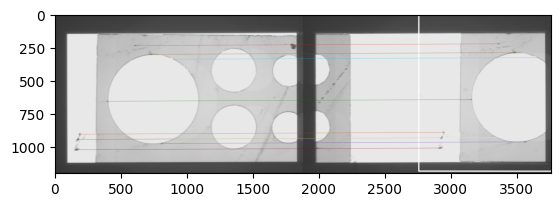

In [ ]:
def get_overlays(img, overlay_width=1000):
    h, w = img.shape[:2]
    print(f"size of image: H={h}, W={w}")
    top_overlay = img[0:overlay_width, :]
    left_overlay = img[:, 0:overlay_width]
    right_overlay = img[:, w-overlay_width:]
    return {"top": top_overlay, "left": left_overlay, "right": right_overlay}

def read_images(img_file, src_file, directory):
    src_path = os.path.join(directory, src_file)
    img_path = os.path.join(directory, img_file)

    src_img = cv.imread(src_path)
    dst_img = cv.imread(img_path)
    src_img = cv.cvtColor(src_img, cv.COLOR_BGR2GRAY)
    dst_img = cv.cvtColor(dst_img, cv.COLOR_BGR2GRAY)
    return (src_img, dst_img)

def image_alignment(dst_img, src_img, display=False):

    # SIFT feature detection and descriptor calculation
    # sift = cv.SIFT_create()

    sift = cv.SIFT_create(
        contrastThreshold=0.04,
        edgeThreshold=10
    )
    src_keypoints, src_descriptors = sift.detectAndCompute(src_img, None)
    dst_keypoints, dst_descriptors = sift.detectAndCompute(dst_img, None)

    # Use kdtrees to find nearest neighbors
    # trees: neighborhood size
    # checks: more checks → searches more of the trees → more accurate matches
    FLANN_INDEX_KDTREE = 1
    NUM_TREES=100
    NUM_CHECKS=100
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=NUM_TREES)
    search_params = dict(checks=NUM_CHECKS)
    flann = cv.FlannBasedMatcher(index_params, search_params)

    # gets the two best matches
    matches = flann.knnMatch(src_descriptors, dst_descriptors, k=2)

    good = []
    for m,n in matches:
        # only keep the best match if it is significantly better than the 2nd best match
        if m.distance < 0.8 * n.distance:
            good.append(m)

    # If we get lower than MIN_MATCH_COUNT matches
    # it is probably not a good match -> abort
    MIN_MATCH_COUNT = 4
    if len(good) < MIN_MATCH_COUNT:
        print(f"not enough matches were found: {len(good)} < {MIN_MATCH_COUNT}")
        matchesMask = None
        return

    src_pts = np.float32([src_keypoints[m.queryIdx].pt for m in good]).reshape(-1,1,2)
    dst_pts = np.float32([dst_keypoints[m.trainIdx].pt for m in good]).reshape(-1,1,2)

    # Find homography M that transforms src_pts to dst_pts
    # dst_pts = M * src_pts
    # mask: Nx1 array --> 1: inlier, 0: outlier
    M, mask = cv.estimateAffinePartial2D(src_pts, dst_pts, cv.RANSAC, ransacReprojThreshold=3, maxIters=2000, confidence=0.99, refineIters=10)

    matchesMask = mask.ravel().tolist()

    ################## Evaluation ##################

    M = np.vstack([M, [0, 0, 1]])
    print(M)

    # inlier ratio
    num_inliers = sum(matchesMask)
    inlier_ratio = num_inliers / len(matchesMask)
    print(f"Inlier ratio: {inlier_ratio}")

    # apply homography on src points and calculate distance to dst points
    # only considering inliers
    src_pts = cv.perspectiveTransform(src_pts, M)
    error = 0
    for i in range(0, len(matchesMask)):
        if matchesMask[i] == 1: # inlier
            [delta_x, delta_y] = src_pts[i][0] - dst_pts[i][0]
            error += (np.pow(delta_x, 2) + np.pow(delta_y, 2))
    error /= num_inliers
    error = np.sqrt(error)
    print(f"RMS error between inliers={error}")

    if display:
        # show boundary of src on dst after homography
        h,w = src_img.shape[:2]
        pts = np.float32([[0,0],[0,h-1],[w-1,h-1],[w-1,0]]).reshape(-1,1,2)
        dst = cv.perspectiveTransform(pts, M)
        dst = np.int32(dst).reshape((-1, 1, 2))
        dst_img = cv.polylines(dst_img, [np.int32(dst)], True, 255, 8, cv.LINE_AA)

        # draw matches
        draw_params = dict(matchColor = None, # draw matches in green color
                        singlePointColor = None,
                        matchesMask = matchesMask, # draw only inliers
                        flags = cv.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS)
        img3 = cv.drawMatches(src_img, src_keypoints, dst_img, dst_keypoints, good, None, **draw_params)
        plt.imshow(img3, 'gray')
        plt.show()

    return (M, error)

if __name__ == "__main__":
    # dst_file = "output_2025-02-06_20-29-57.png"
    # src_file = "output_2025-02-06_20-30-00.png"

    directory = "/content/drive/Shareddrives/Hacker Fab Students/Hacker Fab Students/Projects/Spring 2026 Projects/Stepper/Checkpoint 3/image_stitching_data/data_collection_20260409_132334/"
    dst_file = "tile_1_0.png"
    src_file = "tile_1_1.png"
    dst_img, src_img = read_images(dst_file, src_file, directory)

    gaussian_kernel_size = (5, 5)
    dst_img = cv.GaussianBlur(dst_img, gaussian_kernel_size, 0)
    src_img = cv.GaussianBlur(src_img, gaussian_kernel_size, 0)
    # overlays = get_overlays(src_img)
    # rotated_overlay = cv.rotate(overlays["top"], cv.ROTATE_90_CLOCKWISE)
    image_alignment(dst_img, src_img, True)

In [ ]:
def segment_image(img, tile_width, tile_height, overlay, directory, info_file = "info.txt"):
    h, w = img.shape[:2]
    segmented = []
    for row in range(0, h, tile_height - overlay):
        row_imgs = []
        for col in range(0, w, tile_width - overlay):
            tile = img[row: row + tile_height, col: col + tile_width]

            pad_h = tile_height - tile.shape[0]
            pad_w = tile_width - tile.shape[1]

            if pad_h > 0 or pad_w > 0:
                tile = cv.copyMakeBorder(tile, 0, pad_h, 0, pad_w, cv.BORDER_CONSTANT, value=0)
            row_imgs.append(tile)

        segmented.append(row_imgs)

    rows = len(segmented)
    cols = len(segmented[0])

    for row in range(rows):
        for col in range(cols):
            filename = os.path.join(directory, f"tile_{row}_{col}.png")
            cv.imwrite(filename, segmented[row][col])

    info = {"rows": rows, "cols": cols}
    info_file_path = os.path.join(directory, info_file)
    with open(info_file_path, 'w') as file:
        file.write(json.dumps(info))

def read_info_file(directory, info_file="info.txt"):
    info_file_path = os.path.join(directory, info_file)
    file = open(info_file_path, 'r')
    content = file.read()
    return json.loads(content)

def read_tiles(directory, info):
    rows = info['rows']
    cols = info['cols']

    imgs = []
    img_paths = []
    for row in range(rows):
        row_imgs = []
        row_paths = []
        for col in range(cols):
            img_path = os.path.join(directory, f"tile_{row}_{col}.png")
            row_paths.append(f"tile_{row}_{col}.png")

            img = cv.imread(img_path)
            preprocessed = preprocess_image(img)
            row_imgs.append(preprocessed)
        imgs.append(row_imgs)
        img_paths.append(row_paths)
    return imgs, img_paths

def stitch_images(imgs, img_paths, info, output_path, debug=False):
    # stich images in a snake like pattern
    rows = info['rows']
    cols = info['cols']
    curr_img = None
    next_img = None
    positions = [[0] * cols for _ in range(rows)]
    curr_pos = (0, 0)

    # snake pattern stitching
    for row in range(0, rows):
        col_range = range(0, cols) if row % 2 == 0 else range(cols-1, -1, -1)

        for col in col_range:
            if row == 0 and col == 0:
                curr_img = imgs[0][0]
                curr_path = img_paths[0][0]
                positions[row][col] = curr_pos
                continue

            next_img = imgs[row][col]
            next_path = img_paths[row][col]

            print(f"curr: {curr_path}, next: {next_path}")
            M, error = image_alignment(curr_img, next_img)
            dx = M[0][2]
            dy = M[1][2]
            x, y = curr_pos
            curr_pos = (x + dx, y + dy)
            positions[row][col] = curr_pos
            print(f"should move dx={dx}, dy={dy}")

            curr_img = next_img
            curr_path = next_path

    if debug:
        for row in range(0, rows):
            for col in range(0, cols):
                print(f"row: {row}, col: {col}, position:{positions[row][col]}")

    xs = []
    ys = []

    for row in range(0, rows):
        for col in range(0, cols):
            x, y = positions[row][col]
            h, w = imgs[row][col].shape[:2]

            xs.append(x + w)
            xs.append(x)
            ys.append(y + h)
            ys.append(y)

    canvas_w = int(max(xs) - min(xs))
    canvas_h = int(max(ys) - min(ys))

    print(f"canvas_w={canvas_w}, canvas_h={canvas_h}")

    shift_w = int(min(xs))
    shift_h = int(min(ys))

    print(f"shift_w={shift_w}, shift_h={shift_h}")
    # canvas = np.zeros((canvas_h, canvas_w), dtype=imgs[0][0].dtype)
    canvas = np.zeros((canvas_h, canvas_w), dtype=np.uint8)
    for row in range(rows):
        for col in range(cols):
            img = imgs[row][col]
            h, w = img.shape[:2]
            x, y = positions[row][col]
            x = int(x) - shift_w
            y = int(y) - shift_h
            # shift into canvas coords
            canvas[y:y+h, x:x+w] = img

    # resize by 0.2
    canvas = cv.resize(canvas, None, fx=0.2, fy=0.2)
    # Create a resizable window
    cv.namedWindow('Resized Image Window', cv.WINDOW_NORMAL)

    # Resize the window to your desired dimensions (width, height)
    # cv.resizeWindow('Resized Image Window', 800, 600) # Example size
    # plt.imshow("canvas", canvas)
    # cv.waitKey(0)
    cv.imwrite(output_path, img)

# COPIED TO REPO
def crop_image(img, h_start, h_end, w_start, w_end):
    return img[h_start:h_end, w_start:w_end]

def preprocess_image(img):
    gaussian_kernel_size = (5, 5)
    img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img = cv.GaussianBlur(img, gaussian_kernel_size, 0)
    h, w = img.shape[:2]
    margin_h = 150
    margin_w = margin_h
    img = crop_image(img, margin_h, h - margin_h, margin_w, w - margin_w)
    return img

if __name__ == "__main__":
    image_stitching_directory = "/content/drive/Shareddrives/Hacker Fab Students/Hacker Fab Students/Projects/Spring 2026 Projects/Stepper/Checkpoint 3/image_stitching_data"
    data_directory = "data_collection_20260409_132718"

    directory = os.path.join(image_stitching_directory, data_directory)
    info = read_info_file(directory)
    (imgs, img_paths) = read_tiles(directory, info)

    timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

    output_path = os.path.join(image_stitching_directory, f"output/{timestamp}.png")
    stitch_images(imgs, img_paths, info, output_path, True)


curr: tile_0_0.png, next: tile_0_1.png
[[ 9.99493790e-01 -5.48107845e-04 -8.63086623e+02]
 [ 5.48107845e-04  9.99493790e-01  1.34408821e+01]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Inlier ratio: 0.8173076923076923
RMS error between inliers=0.6996704936027527
should move dx=-863.0866228307067, dy=13.440882057429826
curr: tile_0_1.png, next: tile_0_2.png
[[ 9.99617436e-01 -2.52699853e-04 -8.69493914e+02]
 [ 2.52699853e-04  9.99617436e-01  1.55268738e+01]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Inlier ratio: 0.5652173913043478
RMS error between inliers=0.5262095332145691
should move dx=-869.4939135935488, dy=15.52687378386088
curr: tile_0_2.png, next: tile_0_3.png
[[ 9.99545731e-01 -1.44927635e-04 -8.76038107e+02]
 [ 1.44927635e-04  9.99545731e-01  1.80166107e+01]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Inlier ratio: 0.6037735849056604
RMS error between inliers=0.5114958882331848
should move dx=-876.0381067740318, dy=18.016610673822505
curr: tile_0_3.pn